# 01 — Data loading and inventory check

In this notebook, I load my `image_inventory.csv` file, check that the project folder structure is set up correctly, and make sure the metadata links properly to my cropped images, Weka masks, and probability maps. This gives me a clear starting point before moving on to model training and evaluation.

My overall workflow for this project is: data checking and setup, baseline thresholding, Random Forest classification, CNN classification, and then rollout/evaluation. This notebook is mainly for making sure the dataset is organised correctly and that the image and mask files are connected to the inventory in a consistent way.

Relevant course pages:
- AI algorithms: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_AI_Algorithms.html
- Full-image rollout: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_rollout_3.html

In [1]:
import os
from google.colab import drive

drive.mount('/content/drive')

repo_path = "/content/drive/MyDrive/GEOL0069-sem-segmentation-project"

if not os.path.exists(repo_path):
    !git clone https://github.com/courtneylorabrown/GEOL0069-sem-segmentation-project.git "$repo_path"

%cd /content/drive/MyDrive/GEOL0069-sem-segmentation-project

!mkdir -p data/raw
!mkdir -p data/cropped
!mkdir -p data/masks_weka
!mkdir -p data/probability_maps
!mkdir -p data/metadata
!mkdir -p results
!mkdir -p models
!mkdir -p notebooks


Mounted at /content/drive
/content/drive/MyDrive/GEOL0069-sem-segmentation-project


In [2]:
from pathlib import Path
import pandas as pd
import re

ROOT = Path("/content/drive/MyDrive/GEOL0069-sem-segmentation-project")
INV = ROOT / "data" / "metadata" / "image_inventory.csv"
CROPPED = ROOT / "data" / "cropped"
MASKS = ROOT / "data" / "masks_weka"
PROBS = ROOT / "data" / "probability_maps"

df = pd.read_csv(INV)

# force these columns to text so pandas doesn't warn when filenames are inserted
for col in ["cropped_file", "weka_mask", "probability_map", "split", "notes"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

def clean_stem(filename):
    stem = Path(filename).stem.strip()
    stem = re.sub(r'(?i)Probability maps$', '', stem).strip()
    stem = re.sub(r'(?i)mask$', '', stem).strip()
    stem = re.sub(r'(?i)cropped$', '', stem).strip()
    return stem

def file_map(folder):
    mapping = {}
    for f in folder.iterdir():
        if f.is_file():
            mapping[clean_stem(f.name)] = f.name
    return mapping

cropped_map = file_map(CROPPED)
mask_map = file_map(MASKS)
prob_map = file_map(PROBS)

for i, row in df.iterrows():
    image_id = str(row["image_id"]).strip()

    if image_id in cropped_map:
        df.at[i, "cropped_file"] = cropped_map[image_id]

    if image_id in mask_map:
        df.at[i, "weka_mask"] = mask_map[image_id]

    if image_id in prob_map:
        df.at[i, "probability_map"] = prob_map[image_id]

df.to_csv(INV, index=False)

print("Updated inventory saved to:")
print(INV)
display(df[["image_id", "cropped_file", "weka_mask", "probability_map"]])


Updated inventory saved to:
/content/drive/MyDrive/GEOL0069-sem-segmentation-project/data/metadata/image_inventory.csv


,image_id,cropped_file,weka_mask,probability_map
0,13064_05_17A_400X-8-83,13064_05_17A_400X-8-83cropped.tif,13064_05_17A_400X-8-83mask.tif,
1,13074_00_18A_400X-9-10,13074_00_18A_400X-9-10cropped.tif,13074_00_18A_400X-9-10mask.tif,13074_00_18A_400X-9-10Probability maps.tif
2,13123_00_21A_400X-9-59,13123_00_21A_400X-9-59cropped.tif,13123_00_21A_400X-9-59mask.tif,13123_00_21A_400X-9-59Probability maps.tif
3,R2_10,R2_10cropped.tif,R2_10mask.tif,R2_10Probability maps.tif
4,13064_05_17B_1000X-8-83,13064_05_17B_1000X-8-83cropped.tif,13064_05_17B_1000X-8-83mask.tif,13064_05_17B_1000X-8-83Probability maps.tif
5,13087_50_19B_1000X-9-23,13087_50_19B_1000X-9-23cropped.tif,13087_50_19B_1000X-9-23mask.tif,13087_50_19B_1000X-9-23Probability maps.tif
6,13103_60_20B_1000X-9-39,13103_60_20B_1000X-9-39cropped.tif,13103_60_20B_1000X-9-39mask.tif,13103_60_20B_1000X-9-39Probability maps.tif
7,13123_00_21B_1000X-9-59,13123_00_21B_1000X-9-59cropped.tif,13123_00_21B_1000X-9-59mask.tif,13123_00_21B_1000X-9-59Probability maps.tif
8,13064_05_17C_2000X-8-83,13064_05_17C_2000X-8-83cropped.tif,13064_05_17C_2000X-8-83mask.tif,13064_05_17C_2000X-8-83Probability maps.tif
9,13087_50_19C_2000X-9-23,13087_50_19C_2000X-9-23cropped.tif,13087_50_19C_2000X-9-23mask.tif,13087_50_19C_2000X-9-23Probability maps.tif


In [3]:
import pandas as pd
from pathlib import Path

INV = Path("/content/drive/MyDrive/GEOL0069-sem-segmentation-project/data/metadata/image_inventory.csv")
df = pd.read_csv(INV)

display(df[["image_id", "cropped_file", "weka_mask", "probability_map", "porosity_weka"]])


,image_id,cropped_file,weka_mask,probability_map,porosity_weka
0,13064_05_17A_400X-8-83,13064_05_17A_400X-8-83cropped.tif,13064_05_17A_400X-8-83mask.tif,NaN,1.000000
1,13074_00_18A_400X-9-10,13074_00_18A_400X-9-10cropped.tif,13074_00_18A_400X-9-10mask.tif,13074_00_18A_400X-9-10Probability maps.tif,0.070000
2,13123_00_21A_400X-9-59,13123_00_21A_400X-9-59cropped.tif,13123_00_21A_400X-9-59mask.tif,13123_00_21A_400X-9-59Probability maps.tif,2.268000
3,R2_10,R2_10cropped.tif,R2_10mask.tif,R2_10Probability maps.tif,0.000477
4,13064_05_17B_1000X-8-83,13064_05_17B_1000X-8-83cropped.tif,13064_05_17B_1000X-8-83mask.tif,13064_05_17B_1000X-8-83Probability maps.tif,1.987000
5,13087_50_19B_1000X-9-23,13087_50_19B_1000X-9-23cropped.tif,13087_50_19B_1000X-9-23mask.tif,13087_50_19B_1000X-9-23Probability maps.tif,1.830000
6,13103_60_20B_1000X-9-39,13103_60_20B_1000X-9-39cropped.tif,13103_60_20B_1000X-9-39mask.tif,13103_60_20B_1000X-9-39Probability maps.tif,0.445000
7,13123_00_21B_1000X-9-59,13123_00_21B_1000X-9-59cropped.tif,13123_00_21B_1000X-9-59mask.tif,13123_00_21B_1000X-9-59Probability maps.tif,1.500000
8,13064_05_17C_2000X-8-83,13064_05_17C_2000X-8-83cropped.tif,13064_05_17C_2000X-8-83mask.tif,13064_05_17C_2000X-8-83Probability maps.tif,2.078000
9,13087_50_19C_2000X-9-23,13087_50_19C_2000X-9-23cropped.tif,13087_50_19C_2000X-9-23mask.tif,13087_50_19C_2000X-9-23Probability maps.tif,3.567000


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path('.').resolve()
DATA_DIR = REPO_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
CROPPED_DIR = DATA_DIR / 'cropped'
MASK_DIR = DATA_DIR / 'masks_weka'
PROB_DIR = DATA_DIR / 'probability_maps'
META_DIR = DATA_DIR / 'metadata'
INVENTORY_PATH = META_DIR / 'image_inventory.csv'
RESULTS_DIR = REPO_ROOT / 'results'
MODELS_DIR = REPO_ROOT / 'models'
RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)


def read_gray(path):
    img = Image.open(path).convert('L')
    return np.array(img)


def read_mask(path):
    arr = np.array(Image.open(path).convert('L'))
    return (arr > 0).astype(np.uint8)


def show_pair(image, mask=None, title=''):
    cols = 2 if mask is not None else 1
    fig, axes = plt.subplots(1, cols, figsize=(10, 4))
    if cols == 1:
        axes = [axes]
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(title or 'image')
    axes[0].axis('off')
    if mask is not None:
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title('mask')
        axes[1].axis('off')
    plt.tight_layout()
    plt.show()


def load_inventory(path=INVENTORY_PATH):
    df = pd.read_csv(path)
    if 'porosity_weka' in df.columns:
        df['porosity_weka'] = pd.to_numeric(df['porosity_weka'], errors='coerce')
    return df


def assign_default_split(df):
    if 'split' not in df.columns:
        df['split'] = ''
    df = df.copy()
    for mag, group in df.groupby('actual_magnification'):
        idx = group.sort_values('image_id').index.tolist()
        labels = []
        if len(idx) >= 1:
            labels.extend(['train'] * min(2, len(idx)))
        if len(idx) >= 3:
            labels.append('val')
        while len(labels) < len(idx):
            labels.append('test')
        for i, label in zip(idx, labels):
            if not str(df.loc[i, 'split']).strip():
                df.loc[i, 'split'] = label
    return df


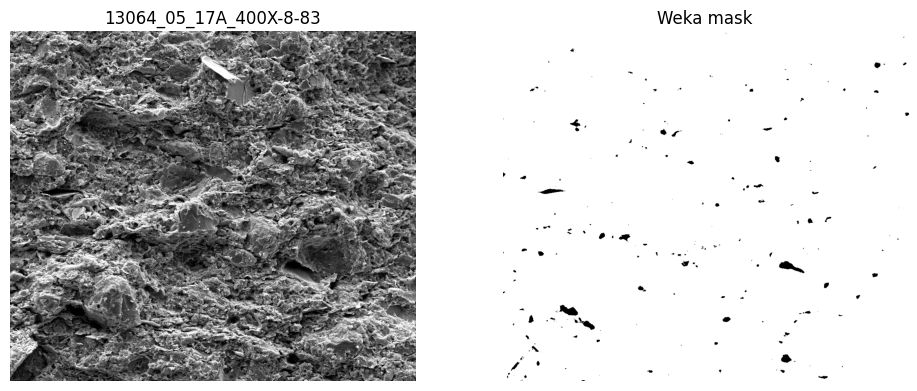

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

ROOT = Path("/content/drive/MyDrive/GEOL0069-sem-segmentation-project")
df = pd.read_csv(ROOT / "data" / "metadata" / "image_inventory.csv")

row = df.iloc[0]

img = np.array(Image.open(ROOT / "data" / "cropped" / row["cropped_file"]).convert("L"))
mask = np.array(Image.open(ROOT / "data" / "masks_weka" / row["weka_mask"]).convert("L"))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img, cmap="gray")
ax[0].set_title(row["image_id"])
ax[0].axis("off")

ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Weka mask")
ax[1].axis("off")

plt.tight_layout()
plt.show()


Measured porosity from displayed Weka mask (%): 1.0004328529882909


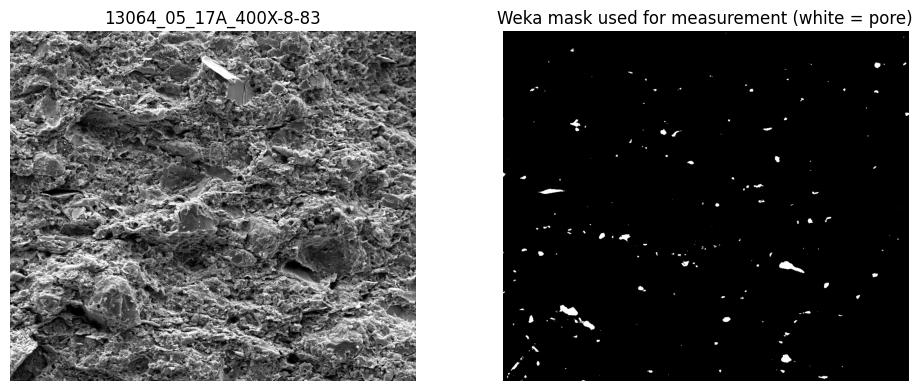

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

ROOT = Path("/content/drive/MyDrive/GEOL0069-sem-segmentation-project")
df = pd.read_csv(ROOT / "data" / "metadata" / "image_inventory.csv")

row = df.iloc[0]

# Load cropped image
img = np.array(
    Image.open(ROOT / "data" / "cropped" / row["cropped_file"]).convert("L")
)

# Load Weka mask and convert to measurement convention:
# dark pixels in the original mask = pore
# internal binary convention = pore = 1, non-pore = 0
weka_raw = np.array(
    Image.open(ROOT / "data" / "masks_weka" / row["weka_mask"]).convert("L")
)
weka_mask = (weka_raw < 128).astype(np.uint8)

# Optional check
print("Measured porosity from displayed Weka mask (%):", weka_mask.mean() * 100)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(img, cmap="gray")
ax[0].set_title(row["image_id"])
ax[0].axis("off")

ax[1].imshow(weka_mask, cmap="gray")
ax[1].set_title("Weka mask used for measurement (white = pore)")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## Notes
- I need to make sure `cropped_file` and `weka_mask` are filled in before I train any supervised models.
- I should keep the train/validation/test split at the **image level**, not the patch level, so patches from the same image don’t leak into the test set.
- My `porosity_weka` values will be useful later when I compare model predictions against the Weka-based porosity results.
